# 01 Exploratory Data Analysis – Rama
**Goal:** understand who gets vaccinated and why, before cleaning or modelling.
**Data:** National 2009 H1N1 Flu Survey (26,707 respondents, 35 features, 2 targets).

Hypotheses (see `workflow.md`): H1 beliefs · H2 demographics · H3 preventive behaviours · H4 risk perception · H5 vaccines correlated · H6 doctor recommendation / insurance.

> We look at **associations**, not causes. A survey cannot tell us that a doctor's recommendation *caused* vaccination.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

X = pd.read_csv("../data/training_set_features.csv")
y = pd.read_csv("../data/training_set_labels.csv")
df = X.merge(y, on="respondent_id")        # raw data: we do NOT change df in this notebook
TARGETS = ["h1n1_vaccine", "seasonal_vaccine"]
print(df.shape)
df.head()

(26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


## 1. Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [30]:
print("Duplicate answer rows:", df.drop(columns="respondent_id").duplicated().sum())
print("Unique respondent ids:", df["respondent_id"].is_unique)
df.describe().T.round(2)

Duplicate answer rows: 0
Unique respondent ids: True


,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.0,13353.00,7709.79,0.0,6676.5,13353.0,20029.5,26706.0
h1n1_concern,26615.0,1.62,0.91,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.26,0.62,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.05,0.22,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.73,0.45,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.07,0.25,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,26625.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,26579.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0


In [4]:
# Categorical columns: how many categories?
cat_cols = df.select_dtypes(include=["object", "string"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

employment_occupation    23
employment_industry      21
hhs_geo_region           10
age_group                 5
education                 4
race                      4
income_poverty            3
employment_status         3
census_msa                3
sex                       2
marital_status            2
rent_or_own               2
dtype: int64

## 2. Targets (H5, RQ4)

h1n1_vaccine        21.2
seasonal_vaccine    46.6
dtype: float64


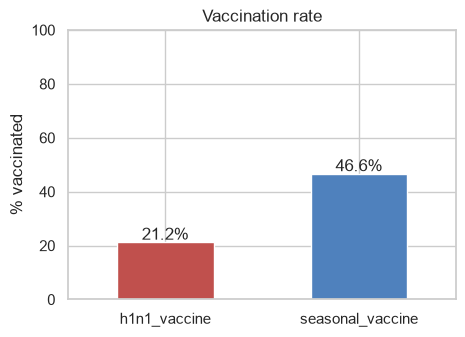

In [5]:
rates = df[TARGETS].mean().mul(100).round(1)
print(rates)
ax = rates.plot.bar(color=["#c0504d", "#4f81bd"], rot=0, figsize=(5, 3.5))
ax.set_ylabel("% vaccinated"); ax.set_title("Vaccination rate"); ax.set_ylim(0, 100)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 1), ha="center")
plt.show()

Correlation between the two targets: 0.38


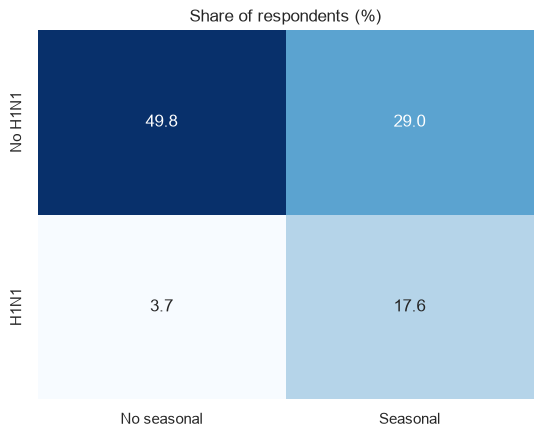

P(H1N1 | seasonal vaccinated)    = 0.378
P(H1N1 | not seasonal vaccinated)= 0.068


In [6]:
print("Correlation between the two targets:", round(df[TARGETS].corr().iloc[0, 1], 2))
ct = pd.crosstab(df["h1n1_vaccine"], df["seasonal_vaccine"], normalize=True).mul(100).round(1)
ct.index = ["No H1N1", "H1N1"]; ct.columns = ["No seasonal", "Seasonal"]
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", cbar=False)
plt.title("Share of respondents (%)"); plt.show()

print("P(H1N1 | seasonal vaccinated)    =", round(df.loc[df.seasonal_vaccine == 1, "h1n1_vaccine"].mean(), 3))
print("P(H1N1 | not seasonal vaccinated)=", round(df.loc[df.seasonal_vaccine == 0, "h1n1_vaccine"].mean(), 3))

**Reading:** H1N1 uptake is about 21% and seasonal about 47%, so the classes are imbalanced (use stratified CV and ROC AUC). The two behaviours are related: people who got the seasonal vaccine are far more likely to also have the H1N1 vaccine.

## 3. Missing values

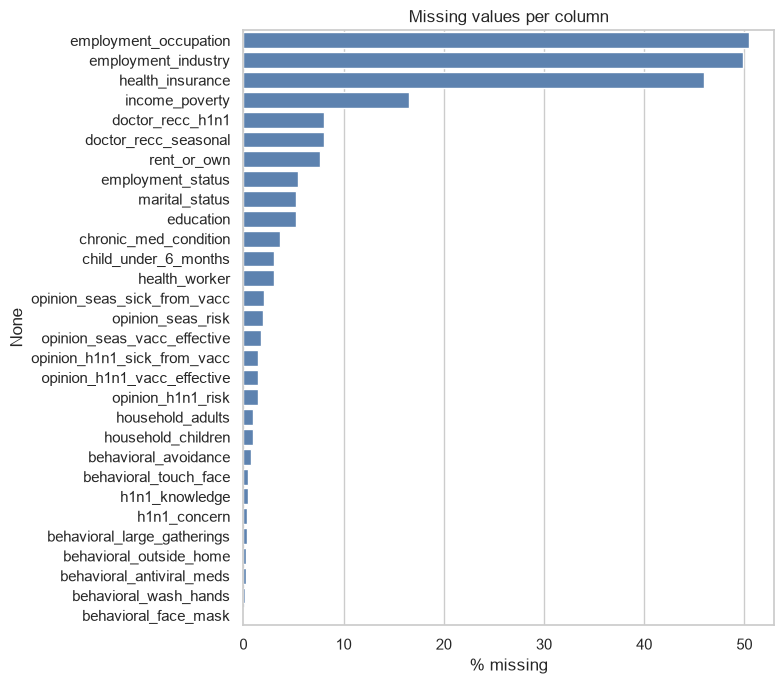

In [7]:
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=missing.values, y=missing.index, color="#4f81bd", ax=ax)
ax.set_xlabel("% missing"); ax.set_title("Missing values per column")
plt.tight_layout(); plt.show()

In [8]:
# Is missing related to vaccination? (decides how we clean later)
rows = []
for col in missing.index:
    m = df[col].isnull()
    rows.append({"column": col, "% missing": round(m.mean() * 100, 1),
                 "h1n1 if missing": round(df.loc[m, "h1n1_vaccine"].mean(), 3),
                 "h1n1 if present": round(df.loc[~m, "h1n1_vaccine"].mean(), 3),
                 "seasonal if missing": round(df.loc[m, "seasonal_vaccine"].mean(), 3),
                 "seasonal if present": round(df.loc[~m, "seasonal_vaccine"].mean(), 3)})
pd.DataFrame(rows).head(12)

,column,% missing,h1n1 if missing,h1n1 if present,seasonal if missing,seasonal if present
0,employment_occupation,50.4,0.209,0.216,0.508,0.422
1,employment_industry,49.9,0.208,0.217,0.508,0.423
2,health_insurance,46.0,0.113,0.297,0.424,0.501
3,income_poverty,16.6,0.189,0.217,0.448,0.469
4,doctor_recc_h1n1,8.1,0.086,0.224,0.352,0.476
5,doctor_recc_seasonal,8.1,0.086,0.224,0.352,0.476
6,rent_or_own,7.6,0.194,0.214,0.419,0.469
7,employment_status,5.5,0.185,0.214,0.388,0.470
8,marital_status,5.3,0.182,0.214,0.389,0.470
9,education,5.3,0.186,0.214,0.385,0.470


## 4. A helper: vaccination rate by group
For any column it draws the % vaccinated for both vaccines, shows the group size *n* under each bar, and treats missing answers as their own group.

In [9]:
def _label(v):
    if pd.isna(v):
        return "Missing"
    if isinstance(v, (int, float, np.floating)):
        return str(int(v)) if float(v).is_integer() else str(v)
    return str(v)

def uptake_by(col, order=None, rotate=0, figsize=(9, 4)):
    d = df[[col] + TARGETS].copy()
    d[col] = d[col].map(_label)
    rate = d.groupby(col)[TARGETS].mean().mul(100)
    n = d.groupby(col).size()
    if order is None:
        order = sorted(rate.index, key=lambda s: (s == "Missing", s))
    rate, n = rate.loc[order], n.loc[order]
    ax = rate.plot.bar(figsize=figsize, color=["#c0504d", "#4f81bd"], rot=rotate, width=0.8)
    ax.set_xticklabels([f"{i}\n(n={n[i]:,})" for i in rate.index], rotation=rotate)
    for t, c in zip(TARGETS, ["#c0504d", "#4f81bd"]):
        ax.axhline(df[t].mean() * 100, color=c, ls="--", lw=1, alpha=0.6)
    ax.set_ylabel("% vaccinated"); ax.set_xlabel(""); ax.set_title(f"Vaccination rate by {col}")
    ax.legend(["h1n1 (overall)", "seasonal (overall)", "h1n1", "seasonal"][2:], loc="upper left")
    plt.tight_layout(); plt.show()
    return rate.round(1)

## 5. Demographics (H2, RQ1, RQ2, RQ5)

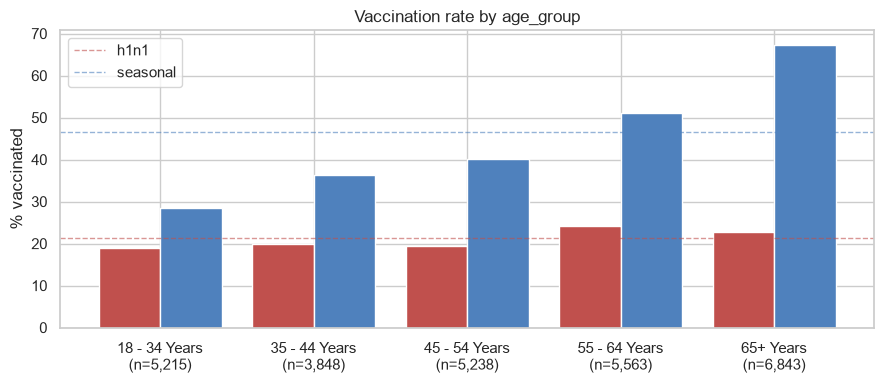

,h1n1_vaccine,seasonal_vaccine
age_group,,
18 - 34 Years,19.0,28.5
35 - 44 Years,19.8,36.3
45 - 54 Years,19.5,40.1
55 - 64 Years,24.3,51.1
65+ Years,22.7,67.4


In [10]:
uptake_by("age_group")

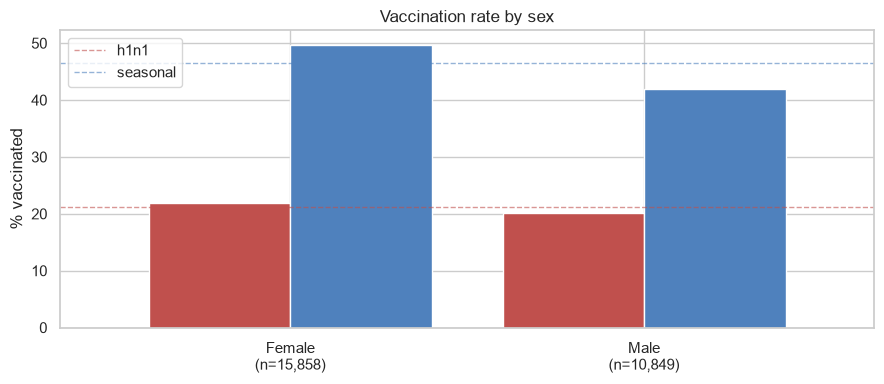

,h1n1_vaccine,seasonal_vaccine
sex,,
Female,21.9,49.7
Male,20.2,41.9


In [11]:
uptake_by("sex")

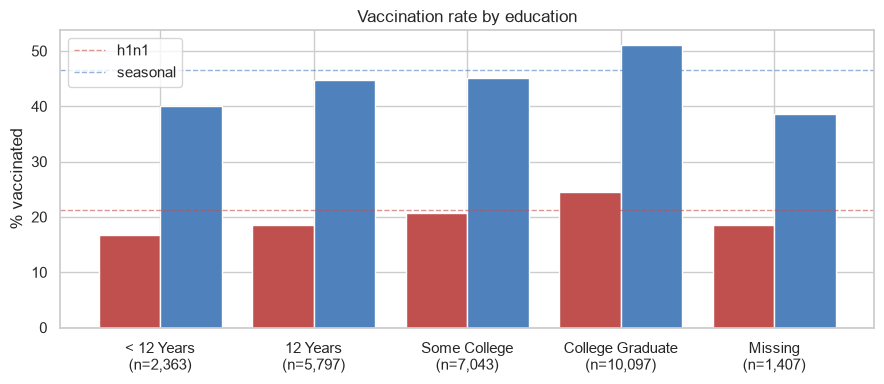

,h1n1_vaccine,seasonal_vaccine
education,,
< 12 Years,16.7,40.1
12 Years,18.5,44.8
Some College,20.8,45.2
College Graduate,24.6,51.1
Missing,18.6,38.5


In [12]:
uptake_by("education", order=["< 12 Years", "12 Years", "Some College", "College Graduate", "Missing"])

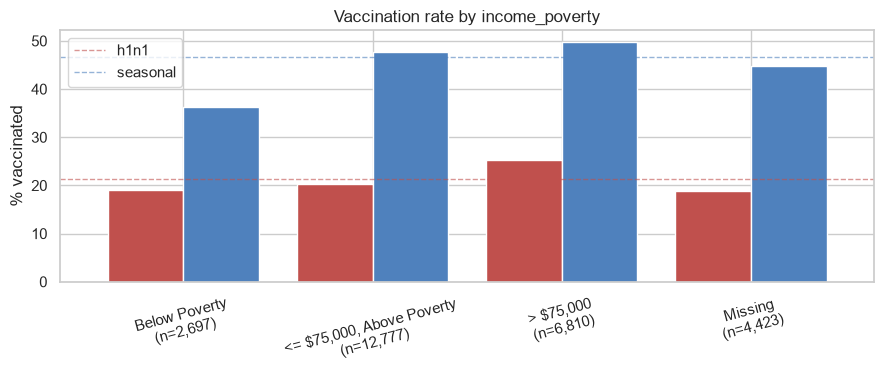

,h1n1_vaccine,seasonal_vaccine
income_poverty,,
Below Poverty,19.1,36.3
"<= $75,000, Above Poverty",20.3,47.7
"> $75,000",25.3,49.7
Missing,18.9,44.8


In [13]:
uptake_by("income_poverty", order=["Below Poverty", "<= $75,000, Above Poverty", "> $75,000", "Missing"], rotate=15)

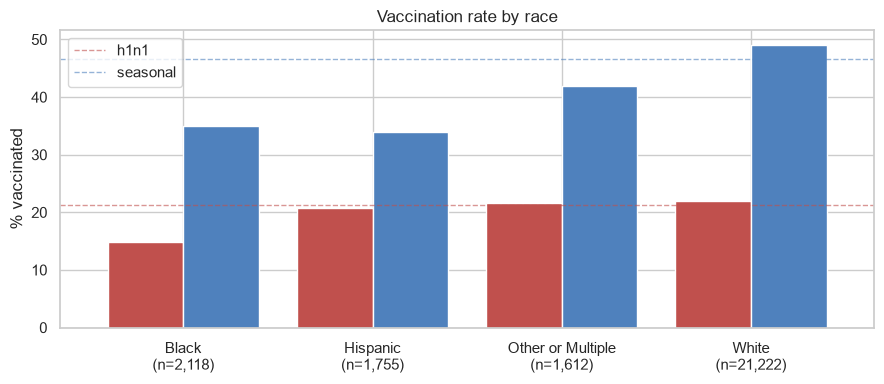

,h1n1_vaccine,seasonal_vaccine
race,,
Black,14.9,35.0
Hispanic,20.8,34.0
Other or Multiple,21.7,42.0
White,21.9,49.1


In [14]:
uptake_by("race")

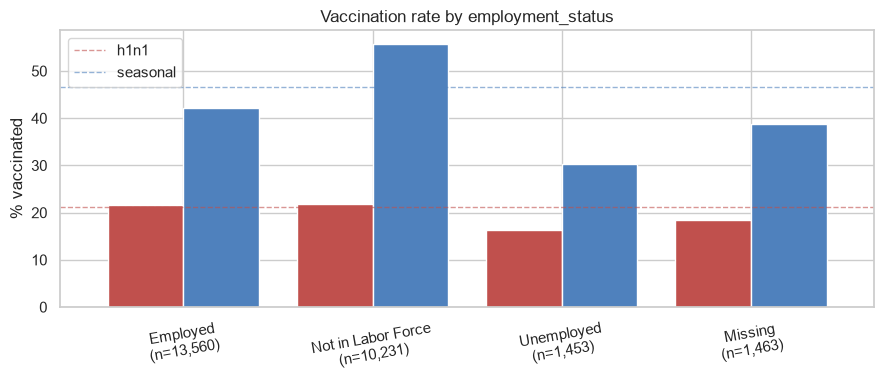

,h1n1_vaccine,seasonal_vaccine
employment_status,,
Employed,21.6,42.2
Not in Labor Force,21.9,55.8
Unemployed,16.3,30.2
Missing,18.5,38.8


In [15]:
uptake_by("employment_status", rotate=10)

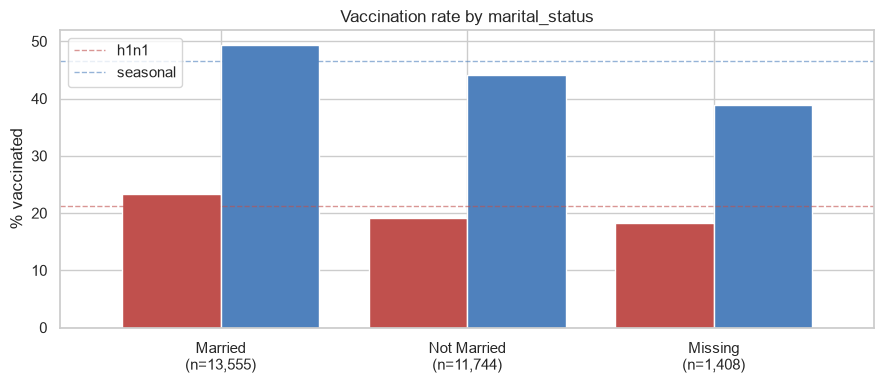

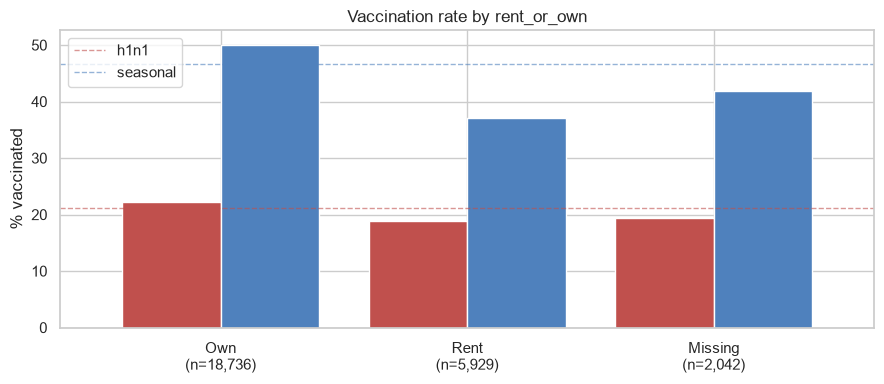

,h1n1_vaccine,seasonal_vaccine
rent_or_own,,
Own,22.2,50.1
Rent,18.9,37.1
Missing,19.4,41.9


In [16]:
uptake_by("marital_status")
uptake_by("rent_or_own")

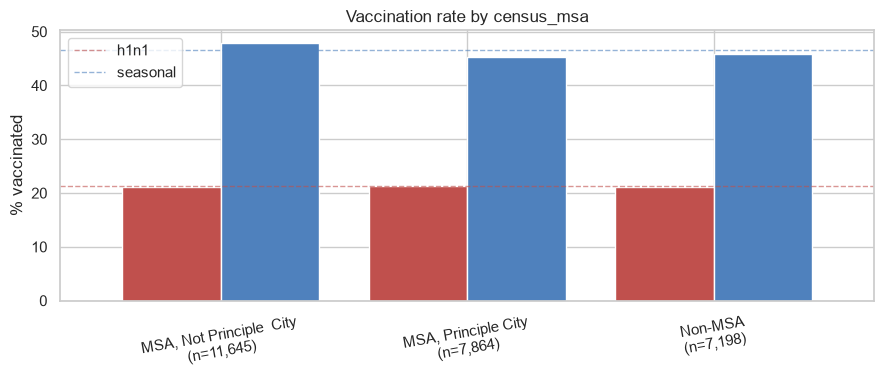

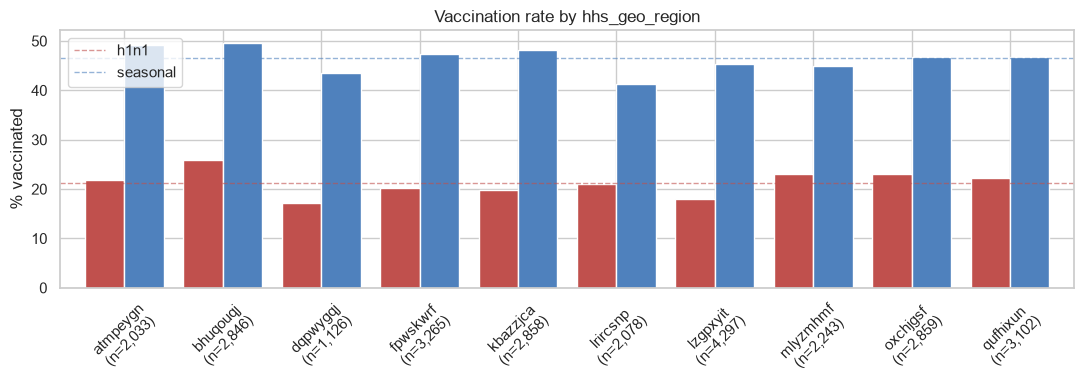

,h1n1_vaccine,seasonal_vaccine
hhs_geo_region,,
atmpeygn,21.7,49.3
bhuqouqj,25.9,49.6
dqpwygqj,17.1,43.4
fpwskwrf,20.2,47.4
kbazzjca,19.8,48.1
lrircsnp,21.0,41.3
lzgpxyit,18.0,45.3
mlyzmhmf,23.0,44.9
oxchjgsf,23.1,46.8


In [17]:
uptake_by("census_msa", rotate=10)
uptake_by("hhs_geo_region", rotate=45, figsize=(11, 4))

**Reading (check against the plots):**
- **Age** has a strong effect for the *seasonal* vaccine (28% for 18–34 up to 67% for 65+) but only a weak one for H1N1 (about 19–24%).
- **Education/income:** college graduates and higher earners vaccinate somewhat more; below poverty is lower for seasonal (36%).
- **Race:** Black and Hispanic respondents have lower seasonal uptake (about 35%) than White respondents (49%); Black respondents have the lowest H1N1 uptake (15%).
- **Employment:** people *not in the labour force* have the highest seasonal uptake, probably because this group includes many retired people (age confounding).
- **Urban/rural (`census_msa`)** makes almost no difference.

## 6. Health and access (H6, RQ3, RQ6)

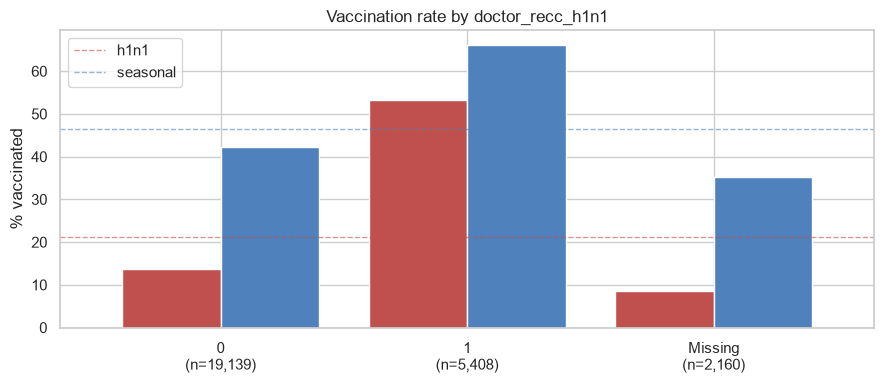

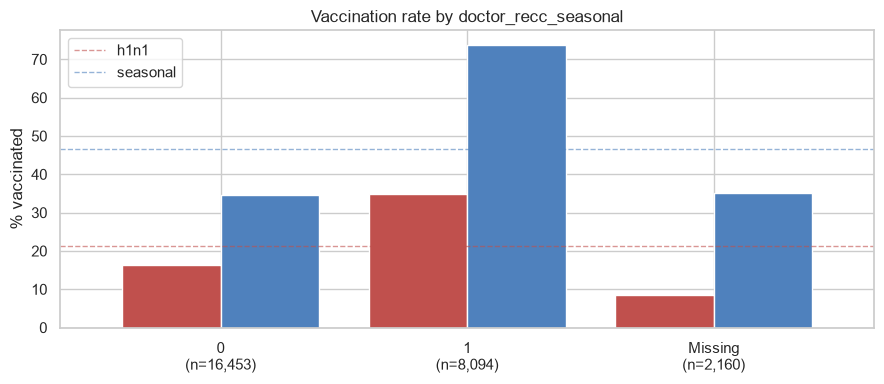

,h1n1_vaccine,seasonal_vaccine
doctor_recc_seasonal,,
0,16.2,34.6
1,34.8,73.8
Missing,8.6,35.2


In [18]:
uptake_by("doctor_recc_h1n1")
uptake_by("doctor_recc_seasonal")

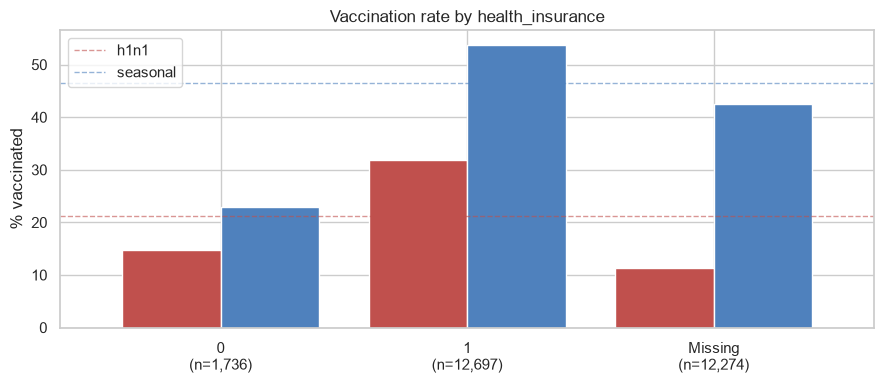

,h1n1_vaccine,seasonal_vaccine
health_insurance,,
0,14.7,22.9
1,31.8,53.8
Missing,11.3,42.4


In [19]:
uptake_by("health_insurance")

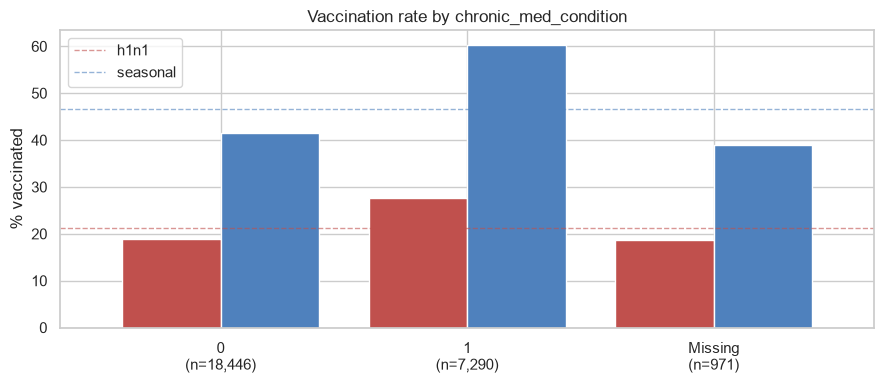

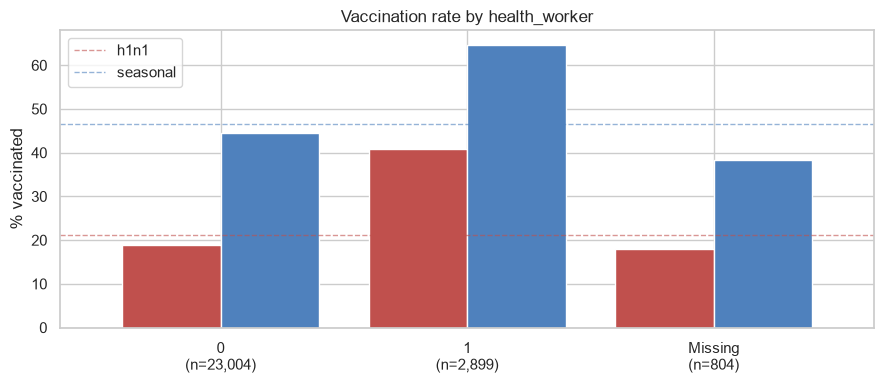

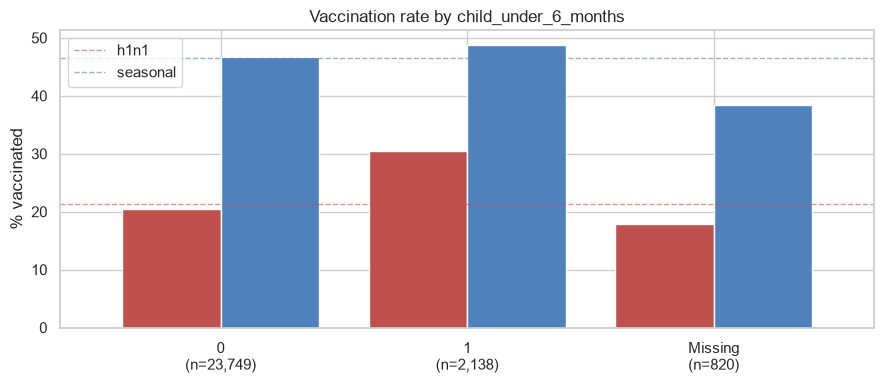

,h1n1_vaccine,seasonal_vaccine
child_under_6_months,,
0,20.5,46.6
1,30.5,48.8
Missing,17.9,38.4


In [20]:
uptake_by("chronic_med_condition")
uptake_by("health_worker")
uptake_by("child_under_6_months")

**Reading:** a doctor's recommendation shows the largest gap: H1N1 uptake is about **53%** with a recommendation and **14%** without; for seasonal about 74% vs 35%. Health workers (41% H1N1) and people with chronic conditions (60% seasonal) also vaccinate much more. People with **missing** insurance or recommendation answers are a distinct group with *lower* uptake, so missing is informative.

## 7. Opinions and risk perception (H1, H4)

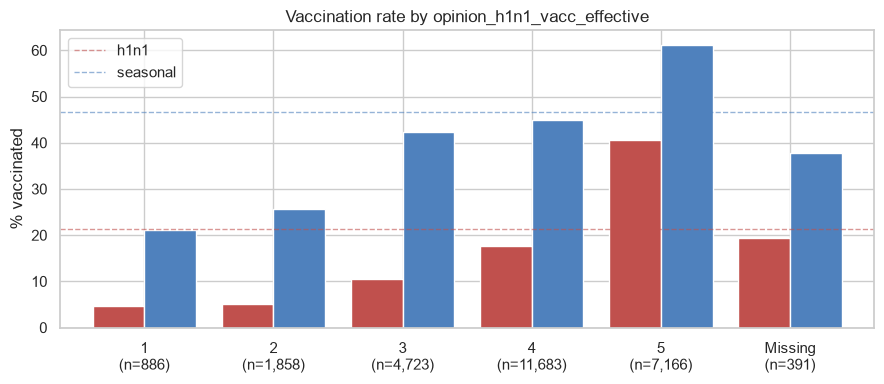

,h1n1_vaccine,seasonal_vaccine
opinion_h1n1_vacc_effective,,
1,4.7,21.1
2,5.1,25.7
3,10.6,42.3
4,17.6,44.8
5,40.5,61.2
Missing,19.4,37.9


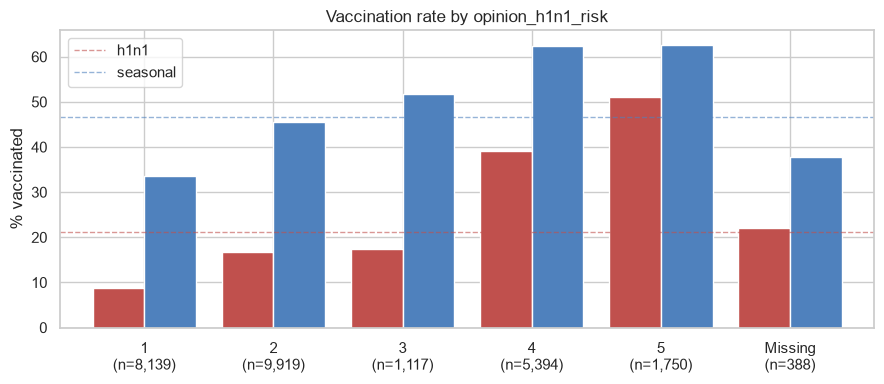

,h1n1_vaccine,seasonal_vaccine
opinion_h1n1_risk,,
1,8.8,33.6
2,16.8,45.5
3,17.4,51.7
4,39.2,62.4
5,51.1,62.7
Missing,22.2,37.9


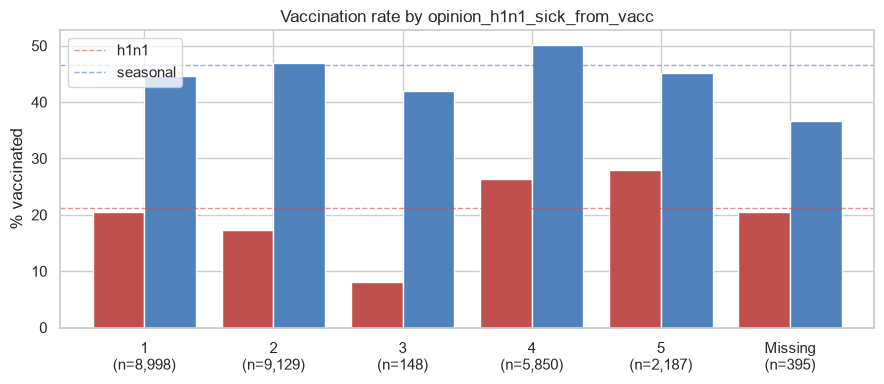

,h1n1_vaccine,seasonal_vaccine
opinion_h1n1_sick_from_vacc,,
1,20.5,44.6
2,17.3,47.0
3,8.1,41.9
4,26.4,50.2
5,28.0,45.2
Missing,20.5,36.7


In [21]:
for col in ["opinion_h1n1_vacc_effective", "opinion_h1n1_risk", "opinion_h1n1_sick_from_vacc"]:
    display(uptake_by(col))

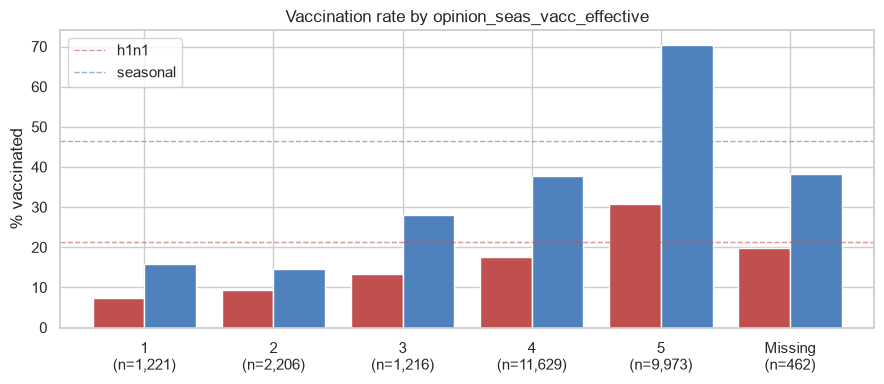

,h1n1_vaccine,seasonal_vaccine
opinion_seas_vacc_effective,,
1,7.3,15.8
2,9.3,14.6
3,13.3,28.0
4,17.6,37.6
5,30.8,70.5
Missing,19.9,38.3


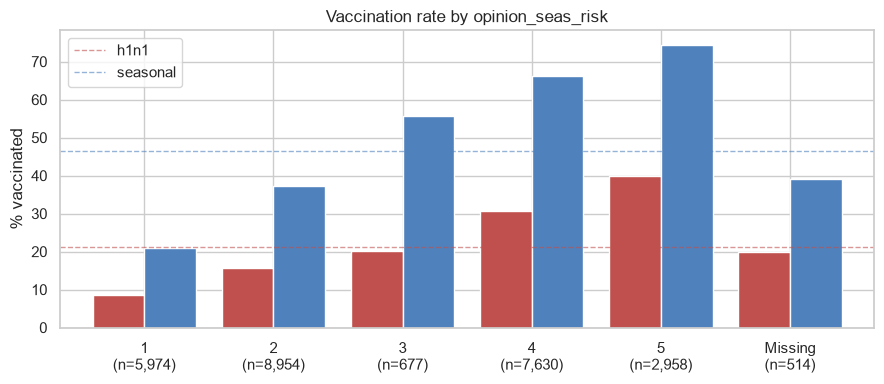

,h1n1_vaccine,seasonal_vaccine
opinion_seas_risk,,
1,8.5,20.9
2,15.8,37.3
3,20.1,55.7
4,30.6,66.3
5,40.0,74.5
Missing,19.8,39.1


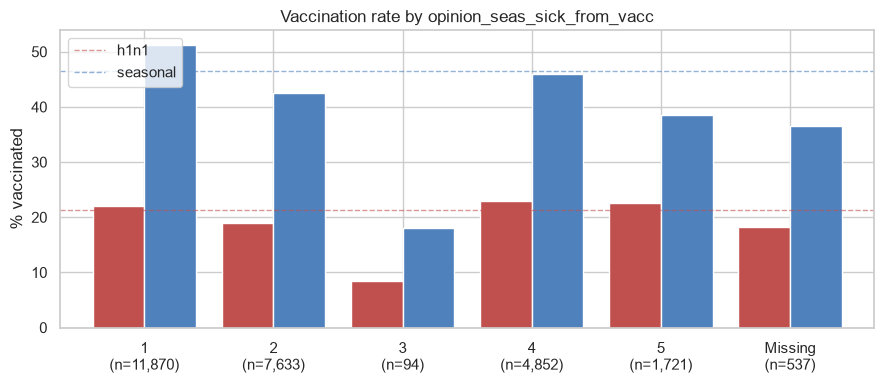

,h1n1_vaccine,seasonal_vaccine
opinion_seas_sick_from_vacc,,
1,22.1,51.3
2,19.0,42.5
3,8.5,18.1
4,22.9,46.0
5,22.5,38.5
Missing,18.2,36.5


In [22]:
for col in ["opinion_seas_vacc_effective", "opinion_seas_risk", "opinion_seas_sick_from_vacc"]:
    display(uptake_by(col))

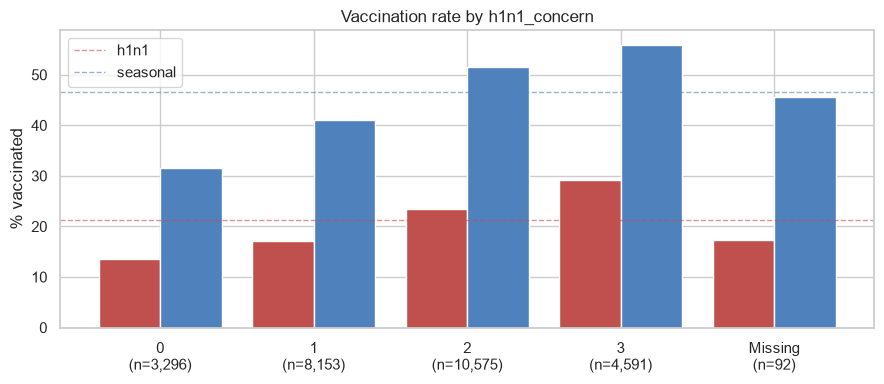

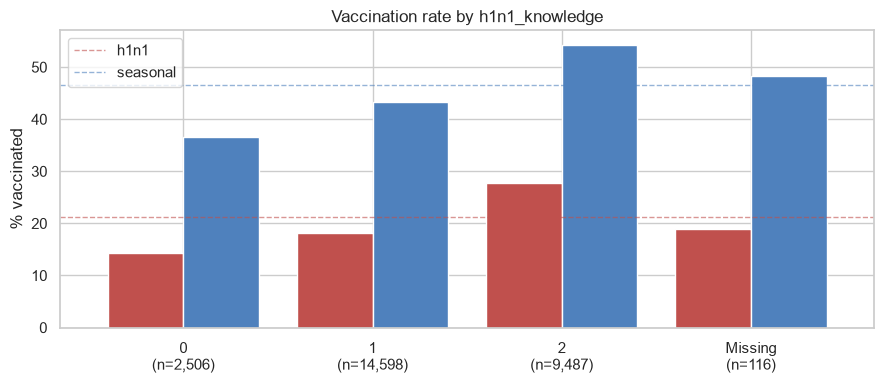

,h1n1_vaccine,seasonal_vaccine
h1n1_knowledge,,
0,14.4,36.6
1,18.2,43.2
2,27.8,54.3
Missing,19.0,48.3


In [23]:
uptake_by("h1n1_concern")
uptake_by("h1n1_knowledge")

**Reading:** perceived **effectiveness** and perceived **risk** show a steady increase in uptake (H1N1 uptake rises from about 5% for "not effective" to 40% for "very effective"). The "worry about getting sick from the vaccine" scale is **not** monotonic, so a plain linear effect would miss it (useful note for Sprint 2).

## 8. Preventive behaviours (H3)

In [24]:
beh = [c for c in df.columns if c.startswith("behavioral_")]
beh_rate = pd.DataFrame({t: [df.loc[df[c] == 1, t].mean() - df.loc[df[c] == 0, t].mean() for c in beh]
                         for t in TARGETS}, index=beh).mul(100).round(1)
beh_rate.columns = ["h1n1: difference (pp)", "seasonal: difference (pp)"]
beh_rate

,h1n1: difference (pp),seasonal: difference (pp)
behavioral_antiviral_meds,7.7,1.5
behavioral_avoidance,4.4,8.5
behavioral_face_mask,11.4,9.9
behavioral_wash_hands,8.1,14.8
behavioral_large_gatherings,1.5,6.7
behavioral_outside_home,1.9,5.6
behavioral_touch_face,6.3,12.8


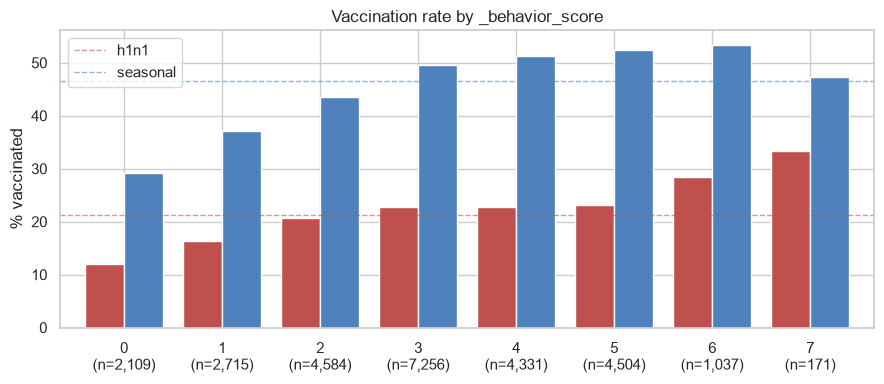

,h1n1_vaccine,seasonal_vaccine
_behavior_score,,
0,12.0,29.3
1,16.3,37.1
2,20.7,43.6
3,22.8,49.6
4,22.7,51.2
5,23.1,52.4
6,28.4,53.4
7,33.3,47.4


In [25]:
df["_behavior_score"] = df[beh].sum(axis=1)       # temporary EDA column
uptake_by("_behavior_score")

**Reading:** people who wash hands, wear masks, touch their face less and avoid contacts vaccinate more, but the effect per behaviour is modest. A simple score adds up behaviours and shows a gradual increase (for H1N1 from about 12% with zero behaviours to 28–33% with 6–7).

## 9. Household

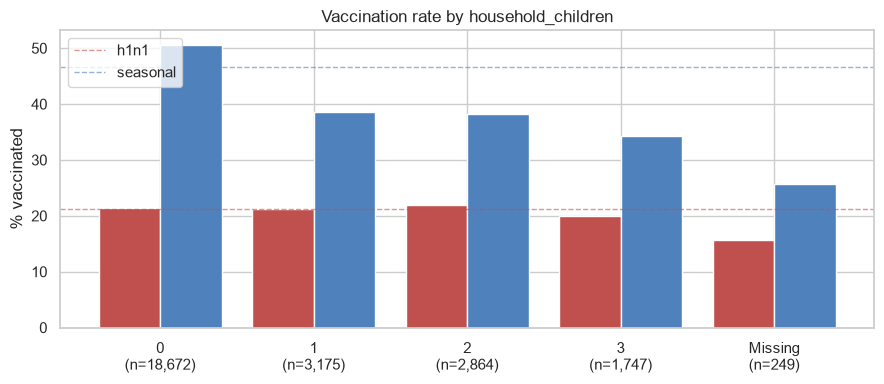

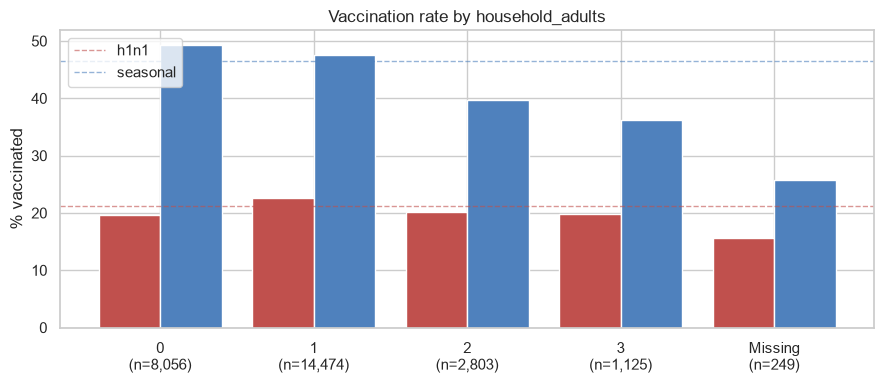

,h1n1_vaccine,seasonal_vaccine
household_adults,,
0,19.7,49.4
1,22.6,47.5
2,20.1,39.7
3,19.7,36.3
Missing,15.7,25.7


In [26]:
uptake_by("household_children")
uptake_by("household_adults")

## 10. Correlation with the targets

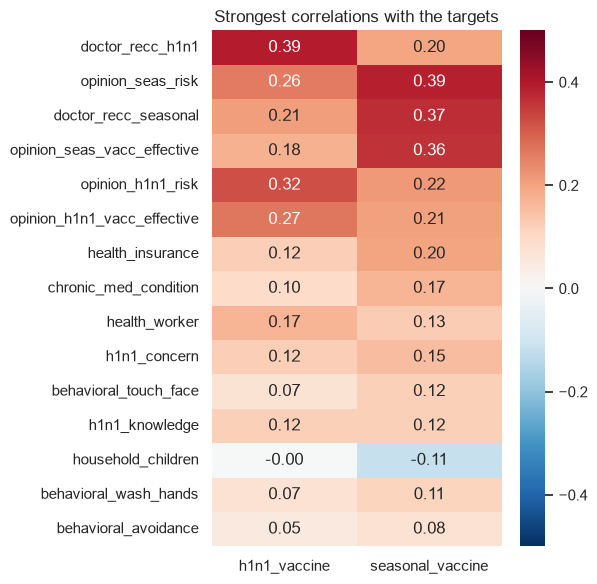

In [27]:
num = df.select_dtypes("number").drop(columns=["respondent_id", "_behavior_score"])
corr = num.corr()[TARGETS].drop(TARGETS)
top = corr.reindex(corr.abs().max(axis=1).sort_values(ascending=False).index).head(15)
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(top, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("Strongest correlations with the targets"); plt.tight_layout(); plt.show()

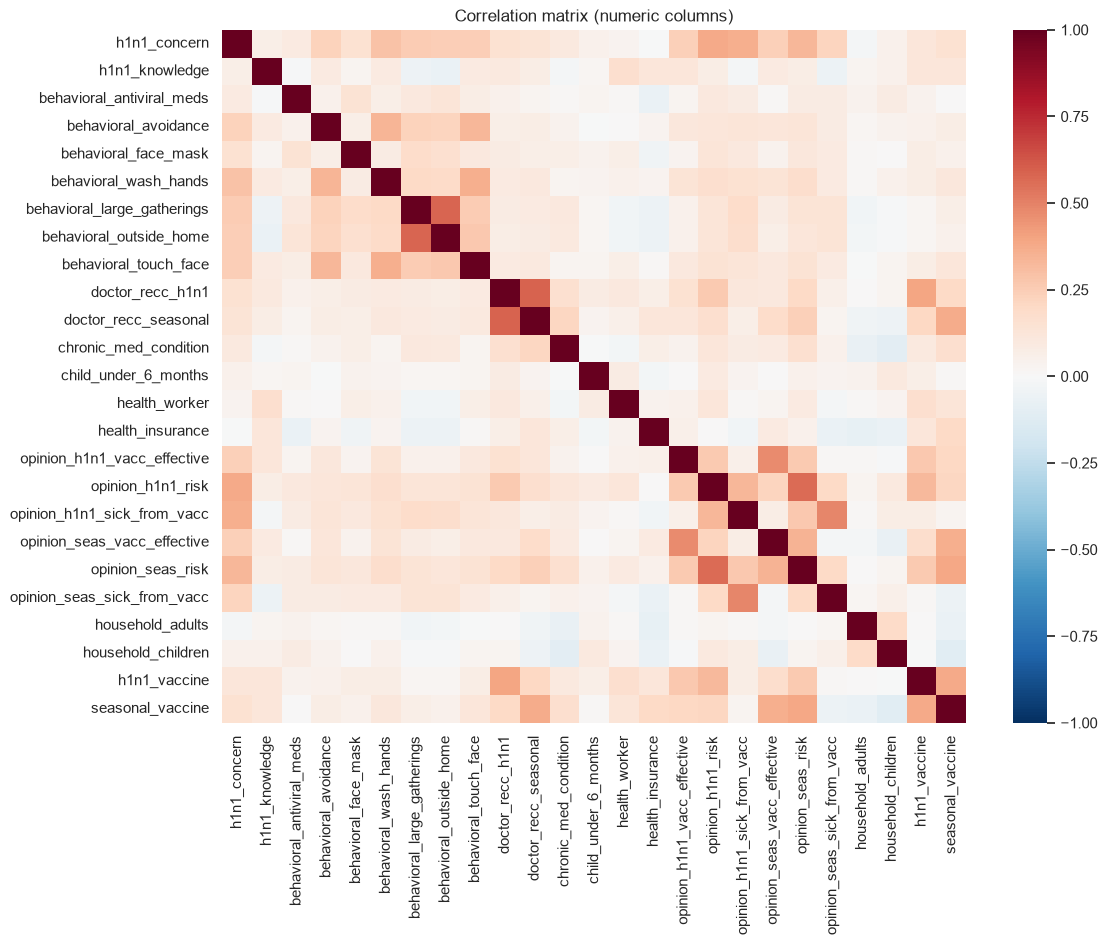

In [28]:
# Full correlation heatmap of the numeric columns (opinions / behaviours cluster together)
plt.figure(figsize=(12, 9))
sns.heatmap(num.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric columns)"); plt.show()

## 11. Summary of findings
Fill in with your own words after you run the notebook.

| Hypothesis | Evidence | Verdict |
|---|---|---|
| H1 Beliefs | Effectiveness opinions: H1N1 uptake 5% → 40% | Supported |
| H2 Demographics | Age matters a lot for seasonal, little for H1N1 | Partly supported |
| H3 Behaviours | Modest, gradual increase with behaviour score | Weak–moderate |
| H4 Risk perception | Higher perceived risk → higher uptake | Supported |
| H5 Cross-vaccine | P(H1N1 \| seasonal) = 0.38 vs 0.07 | Supported |
| H6 Doctor / insurance | Largest gaps of any feature | Supported |

**Limits:** associations only; self-reported data; survey from 2009–2010; missing data is not random; age and employment are entangled (retired people).

**Next:** `02_data_cleaning_<name>.ipynb`.